### Оценка эффекта вирусного флешмоба методом CausalImpact

**Цель анализа:** Оценить чистый (причинно-следственный) эффект от проведенного пользователями флешмоба на ряд метрик, исключив влияние естественных колебаний других метрик.

**Специфика метрик:**
* `DAU` и `Views` выступают предикторами общего трафика платформы.
* `New_Posts` отражает генерацию контента.
* `Unique_Viewed_Posts` выбрана в качестве целевой переменной ($Y$). Она учитывает структуру социальной сети: один и тот же пост может просматриваться в разные дни разными пользователями, поэтому всплеск этой метрики покажет реальное расширение сетевого взаимодействия.

**Методология:** 
Используется базовая байесовская модель структурных временных рядов (Structural Time-Series) в конфигурации *Local Level* (без включения компонентов линейного тренда и сезонности). Модель строит контрфактуал (прогноз того, как вела бы себя целевая метрика без флешмоба) на основе поведения ковариат в `pre_period`, а затем сравнивает его с фактическими данными в `post_period`.


In [1]:
#общие для обработки данных
import pandas as pd
import pandahouse as ph

#общие штуки для рисования
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_probability as tfp

from causalimpact import CausalImpact
from tqdm import tqdm

2026-05-16 12:49:16.746421: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 12:49:16.751440: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-16 12:49:17.061307: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-16 12:49:17.142876: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-16 12:49:23.554485: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [2]:
# Параметры подключения
connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator_20260420'
}

In [3]:
query = '''
SELECT 
    toDate(time) as date,
    COUNT(DISTINCT user_id) as DAU,
    countIf(action = 'like')/countIf(action = 'view') as CTR,
    countIf(action = 'view') as count_of_views,
    COUNT(DISTINCT post_id) AS unique_posts
FROM 
    {db}.feed_actions
GROUP BY date
ORDER BY date
'''

In [4]:
query_2 = '''
SELECT first_date as date,
    COUNT(post_id) as new_posts
FROM (    
SELECT 
    post_id,
    MIN(toDate(time)) AS first_date
FROM 
    {db}.feed_actions
GROUP BY post_id     
ORDER BY post_id     
) t1
GROUP BY date
'''

In [5]:
activity = ph.read_clickhouse(query=query, connection=connection)
activity.head()

,date,DAU,CTR,count_of_views,unique_posts
0,2026-03-07,878,0.205182,7603,89
1,2026-03-08,2238,0.204174,62770,178
2,2026-03-09,3105,0.198605,105526,191
3,2026-03-10,3721,0.200007,118996,211
4,2026-03-11,4617,0.197783,174454,214


In [6]:
activity_new_posts = ph.read_clickhouse(query=query_2, connection=connection)

In [7]:
activity = activity.merge(activity_new_posts, on = 'date')
activity.head()

,date,DAU,CTR,count_of_views,unique_posts,new_posts
0,2026-03-07,878,0.205182,7603,89,89
1,2026-03-08,2238,0.204174,62770,178,97
2,2026-03-09,3105,0.198605,105526,191,61
3,2026-03-10,3721,0.200007,118996,211,87
4,2026-03-11,4617,0.197783,174454,214,70


In [8]:
# Преобразование индекса в нужный формат
activity['date'] = pd.to_datetime(activity['date'])
activity.set_index('date', inplace=True)

In [9]:
# Настройка пред- и пост-периодов
pre_period = ['2026-03-07', '2026-04-16']
post_period = ['2026-04-17', '2026-04-23']

In [10]:
# Задаем метрики
metrics = ['DAU', 'CTR', 'count_of_views', 'unique_posts', 'new_posts']

  0%|          | 0/5 [00:00<?, ?it/s]

Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.while_loop(c, b, vars, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.while_loop(c, b, vars))


2026-05-15 14:55:49.966794: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [1]
	 [[{{node shape}}]]
2026-05-15 14:55:49.966993: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [1]
	 [[{{node shape}}]]
2026-05-15 14:55:49.980022: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [1]
	 [[{{node shape}}]]
2026-05-15 14:55:49.980162: I tens

Instructions for updating:
Please use `StructuralTimeSeries.joint_distribution(observed_time_series).log_prob`


2026-05-15 14:55:53.547772: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:55:53.644847: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_1_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:55:53.751424: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node monte_carlo_variational_loss/expectation/powerInv

Instructions for updating:
`Predictive distributions returned by`tfp.sts.one_step_predictive` will soon compute per-timestep probabilities (treating timesteps as part of the batch shape) instead of a single probability for an entire series (the current approach, in which timesteps are treated as event shape). Please update your code to pass `timesteps_are_event_shape=False` (this will soon be the default) and to explicitly sum over the per-timestep log probabilities if this is required.


2026-05-15 14:56:41.059119: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-05-15 14:56:41.360915: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

Анализ DAU


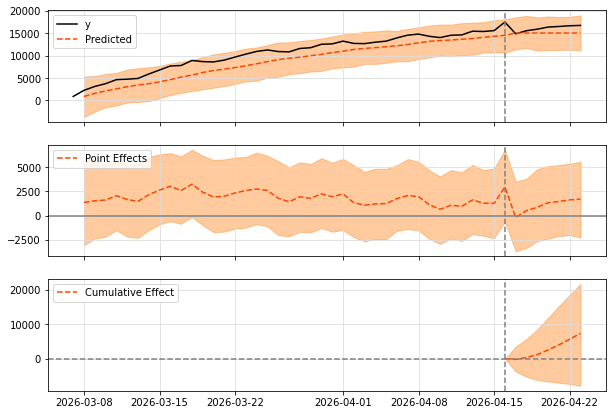

 20%|██        | 1/5 [00:59<03:58, 59.52s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    16052.71           112369.0
Prediction (s.d.)         15004.72 (1115.27) 105033.06 (7806.91)
95% CI                    [12951.51, 17323.29][90660.55, 121263.06]

Absolute effect (s.d.)    1047.99 (1115.27)  7335.94 (7806.91)
95% CI                    [-1270.58, 3101.21][-8894.06, 21708.45]

Relative effect (s.d.)    6.98% (7.43%)      6.98% (7.43%)
95% CI                    [-8.47%, 20.67%]   [-8.47%, 20.67%]

Posterior tail-area probability p: 0.18
Posterior prob. of a causal effect: 82.12%

For more details run the command: print(impact.summary('report'))


2026-05-15 14:56:48.974359: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:56:49.068362: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:56:50.560532: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:

Анализ CTR


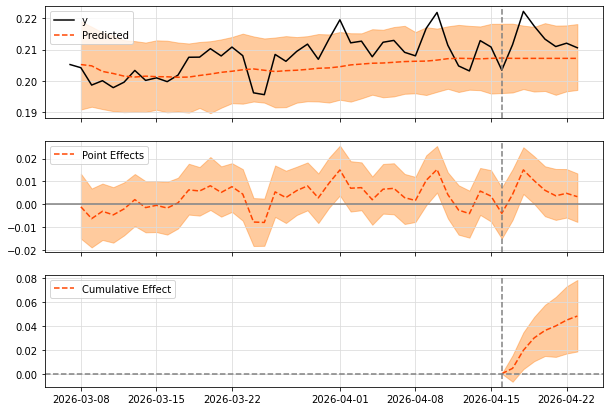

 40%|████      | 2/5 [01:51<02:45, 55.04s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    0.21               1.5
Prediction (s.d.)         0.21 (0.0)         1.45 (0.02)
95% CI                    [0.2, 0.21]        [1.42, 1.48]

Absolute effect (s.d.)    0.01 (0.0)         0.05 (0.02)
95% CI                    [0.0, 0.01]        [0.02, 0.08]

Relative effect (s.d.)    3.31% (1.07%)      3.31% (1.07%)
95% CI                    [1.26%, 5.47%]     [1.26%, 5.47%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 99.9%

For more details run the command: print(impact.summary('report'))


2026-05-15 14:57:40.961419: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:57:41.051597: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:57:42.855412: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:

2026-05-15 14:58:25.354042: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-05-15 14:58:25.484214: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

Анализ count_of_views


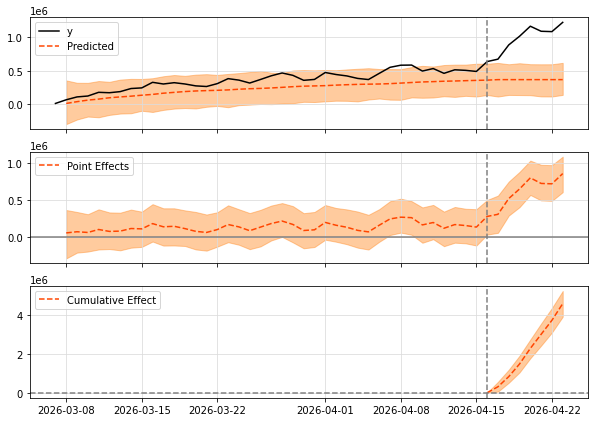

 60%|██████    | 3/5 [02:42<01:46, 53.37s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    1019947.31         7139631.0
Prediction (s.d.)         364957.22 (47657.64)2554700.5 (333603.5)
95% CI                    [272906.24, 459720.79][1910343.58, 3218045.53]

Absolute effect (s.d.)    654990.12 (47657.64)4584930.5 (333603.5)
95% CI                    [560226.52, 747041.07][3921585.47, 5229287.42]

Relative effect (s.d.)    179.47% (13.06%)   179.47% (13.06%)
95% CI                    [153.5%, 204.69%]  [153.5%, 204.69%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


2026-05-15 14:58:32.281060: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:58:32.371209: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:58:34.159294: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:

Анализ unique_posts


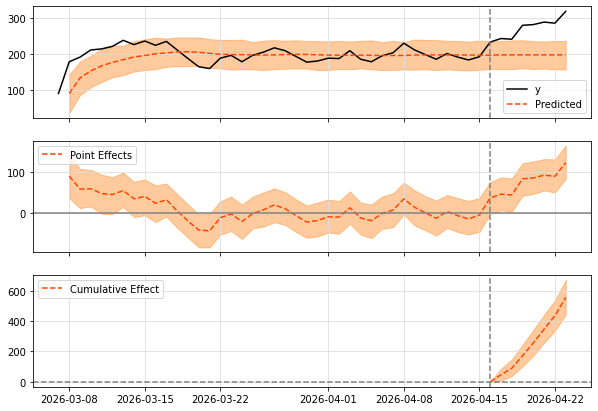

 80%|████████  | 4/5 [03:31<00:51, 51.41s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    277.14             1940.0
Prediction (s.d.)         197.34 (8.28)      1381.4 (57.98)
95% CI                    [180.93, 213.4]    [1266.52, 1493.82]

Absolute effect (s.d.)    79.8 (8.28)        558.6 (57.98)
95% CI                    [63.74, 96.21]     [446.18, 673.48]

Relative effect (s.d.)    40.44% (4.2%)      40.44% (4.2%)
95% CI                    [32.3%, 48.75%]    [32.3%, 48.75%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


2026-05-15 14:59:20.743597: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:59:20.775616: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:59:22.282283: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-15 14:

2026-05-15 15:00:04.950368: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-05-15 15:00:05.150243: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

Анализ new_posts


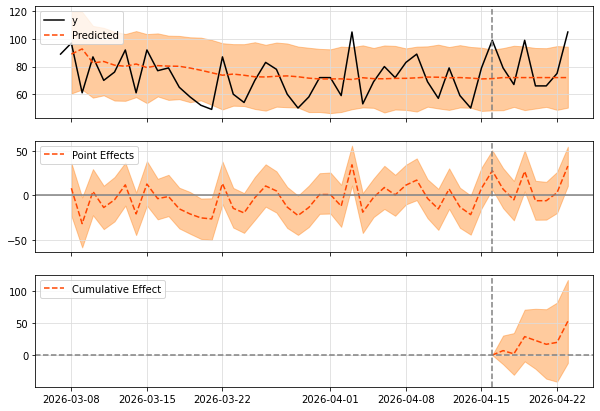

100%|██████████| 5/5 [04:21<00:00, 52.32s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    79.57              557.0
Prediction (s.d.)         72.02 (4.73)       504.11 (33.13)
95% CI                    [62.34, 80.89]     [436.35, 566.22]

Absolute effect (s.d.)    7.56 (4.73)        52.89 (33.13)
95% CI                    [-1.32, 17.24]     [-9.22, 120.65]

Relative effect (s.d.)    10.49% (6.57%)     10.49% (6.57%)
95% CI                    [-1.83%, 23.93%]   [-1.83%, 23.93%]

Posterior tail-area probability p: 0.05
Posterior prob. of a causal effect: 94.81%

For more details run the command: print(impact.summary('report'))


In [11]:
# Применяем CausalImpact

for i in tqdm(metrics):
    impact = CausalImpact(data = activity[i], 
                          pre_period = pre_period, 
                          post_period = post_period)
    print(f'Анализ {i}')
    impact.plot()
    print(impact.summary())

Вывод:  
- DAU значимо не изменилось. 
- CTR значимо, но незначительно вырос. Средняя величина относительного эффекта - примерно 3.31%.  
- Число просмотров значимо выросло. Средняя величина относительного эффекта - примерно 179.47%.      
- Число новых постов значимо не изменилось.  
- Число уникальных просматриваемых постов значимо выросло. Средняя величина относительного эффекта - примерно 40.44%.    